In [2]:
# ── SETUP ──────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

import os, sys

REPO = "https://github.com/Arjun11x/spectral-bridge.git"
if not os.path.exists('/content/spectral-bridge'):
    !git clone {REPO}
else:
    !cd /content/spectral-bridge && git pull

sys.path.insert(0, '/content/spectral-bridge')

!pip install -q tqdm

TRAIN_CSV = "/content/drive/MyDrive/spectral-bridge/data/spectral_graffiti.csv"
TEST_CSV  = "/content/drive/MyDrive/spectral-bridge/data/test_features_spectral.csv"

assert os.path.exists(TRAIN_CSV), f"Training CSV not found at {TRAIN_CSV}"
assert os.path.exists(TEST_CSV),  f"Test CSV not found at {TEST_CSV}"

print("=" * 50)
print("Setup complete!")
print(f"Train CSV : {TRAIN_CSV}")
print(f"Test CSV  : {TEST_CSV}")
print("=" * 50)

Mounted at /content/drive
Cloning into 'spectral-bridge'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 47 (delta 21), reused 36 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 439.86 KiB | 2.53 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Setup complete!
Train CSV : /content/drive/MyDrive/spectral-bridge/data/spectral_graffiti.csv
Test CSV  : /content/drive/MyDrive/spectral-bridge/data/test_features_spectral.csv


In [3]:
# ── Cell 2: Imports ────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import CubicSpline, interp1d
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from src import config
from src.utils import set_seed, ensure_dirs

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

set_seed()
ensure_dirs()

print("Imports done!")

Imports done!


In [4]:
# ── Cell 3: Load and prepare data ─────────────────────────────────────────

df = pd.read_csv(TRAIN_CSV)

# use 2000 samples for baseline evaluation — statistically reliable
# and fast enough to run on CPU without waiting
EVAL_SAMPLES = 2000
unique_ids   = df['Sample_ID'].unique()
np.random.seed(config.SEED)
eval_ids     = np.random.choice(unique_ids, EVAL_SAMPLES, replace=False)
eval_df      = df[df['Sample_ID'].isin(eval_ids)]

print(f"Total samples in dataset : {df['Sample_ID'].nunique():,}")
print(f"Samples used for eval    : {EVAL_SAMPLES:,}")
print(f"Rows in eval subset      : {len(eval_df):,}")

# pre-process into per-sample arrays for fast baseline computation
samples = []
for sid, group in tqdm(eval_df.groupby('Sample_ID'),
                       desc="Preparing samples", leave=False):
    group      = group.sort_values('Time_ms').reset_index(drop=True)
    time       = group['Time_ms'].values
    values     = group['Value'].values
    is_context = group['Is_Context'].values.astype(bool)

    samples.append({
        'id':             sid,
        'time':           time,
        'values':         values,
        'is_context':     is_context,
        'context_time':   time[is_context],
        'context_values': values[is_context],
        'target_time':    time[~is_context],
        'target_values':  values[~is_context],
    })

print(f"\nSample structure (first sample):")
print(f"  Context points : {samples[0]['is_context'].sum()}")
print(f"  Gap positions  : {(~samples[0]['is_context']).sum()}")
print(f"  Context time   : {samples[0]['context_time'][:5]}...")
print(f"  Target time    : {samples[0]['target_time'][:5]}...")

Total samples in dataset : 80,000
Samples used for eval    : 2,000
Rows in eval subset      : 200,000



Sample structure (first sample):
  Context points : 20
  Gap positions  : 80
  Context time   : [ 3  8 12 19 24]...
  Target time    : [1 2 4 5 6]...


In [5]:
# ── Cell 4: Baseline utility function ─────────────────────────────────────

def compute_baseline_mse(samples: list, predict_fn) -> dict:
    """
    Evaluate any baseline prediction function across all samples.

    Args:
        samples    : list of sample dicts from Cell 3
        predict_fn : function that takes a sample dict and returns
                     predicted values for target positions as np.ndarray

    Returns:
        dict with keys:
            mean_mse   : mean MSE across all samples
            median_mse : median MSE across all samples
            std_mse    : std deviation of per-sample MSE
            per_sample : array of per-sample MSE values
    """
    per_sample_mse = []

    for sample in samples:
        try:
            y_pred = predict_fn(sample)
            y_true = sample['target_values']
            mse    = np.mean((y_pred - y_true) ** 2)
            per_sample_mse.append(mse)
        except Exception:
            # some baselines fail on edge cases — skip and continue
            per_sample_mse.append(np.nan)

    per_sample_mse = np.array(per_sample_mse)
    valid          = per_sample_mse[~np.isnan(per_sample_mse)]

    return {
        'mean_mse':   float(np.mean(valid)),
        'median_mse': float(np.median(valid)),
        'std_mse':    float(np.std(valid)),
        'per_sample': per_sample_mse,
    }

print("Utility function defined!")
print("Ready to run baselines.")

Utility function defined!
Ready to run baselines.


In [6]:
# ── Cell 5: Baseline 1 — Zero predictor ───────────────────────────────────

def zero_predictor(sample: dict) -> np.ndarray:
    """Predicts zero for every gap position."""
    return np.zeros(len(sample['target_time']))

zero_results = compute_baseline_mse(samples, zero_predictor)

print("Baseline 1 — Zero predictor")
print(f"  Mean MSE   : {zero_results['mean_mse']:.6f}")
print(f"  Median MSE : {zero_results['median_mse']:.6f}")
print(f"  Std MSE    : {zero_results['std_mse']:.6f}")

Baseline 1 — Zero predictor
  Mean MSE   : 0.311986
  Median MSE : 0.312027
  Std MSE    : 0.003848


In [7]:
# ── Cell 6: Baseline 2 — Mean predictor ───────────────────────────────────

def mean_predictor(sample: dict) -> np.ndarray:
    """Predicts the mean of context values for every gap position."""
    context_mean = sample['context_values'].mean()
    return np.full(len(sample['target_time']), context_mean)

mean_results = compute_baseline_mse(samples, mean_predictor)

print("Baseline 2 — Mean predictor")
print(f"  Mean MSE   : {mean_results['mean_mse']:.6f}")
print(f"  Median MSE : {mean_results['median_mse']:.6f}")
print(f"  Std MSE    : {mean_results['std_mse']:.6f}")
print(f"\n  Improvement over zero : "
      f"{zero_results['mean_mse'] / mean_results['mean_mse']:.1f}x better")

Baseline 2 — Mean predictor
  Mean MSE   : 0.062171
  Median MSE : 0.062068
  Std MSE    : 0.001621

  Improvement over zero : 5.0x better


In [8]:
# ── Cell 7: Baseline 3 — Linear interpolation ─────────────────────────────

def linear_interpolation(sample: dict) -> np.ndarray:
    """
    Fills gaps by drawing straight lines between context points.
    Uses nearest-neighbor extrapolation for gaps outside the
    context range — avoids exploding values at boundaries.
    """
    interpolator = interp1d(
        sample['context_time'],
        sample['context_values'],
        kind='linear',
        bounds_error=False,
        fill_value=(
            sample['context_values'][0],   # left boundary
            sample['context_values'][-1],  # right boundary
        )
    )
    return interpolator(sample['target_time'])

linear_results = compute_baseline_mse(samples, linear_interpolation)

print("Baseline 3 — Linear interpolation")
print(f"  Mean MSE   : {linear_results['mean_mse']:.6f}")
print(f"  Median MSE : {linear_results['median_mse']:.6f}")
print(f"  Std MSE    : {linear_results['std_mse']:.6f}")
print(f"\n  Improvement over zero : "
      f"{zero_results['mean_mse'] / linear_results['mean_mse']:.1f}x better")
print(f"  Improvement over mean : "
      f"{mean_results['mean_mse'] / linear_results['mean_mse']:.1f}x better")

Baseline 3 — Linear interpolation
  Mean MSE   : 0.007958
  Median MSE : 0.006591
  Std MSE    : 0.006008

  Improvement over zero : 39.2x better
  Improvement over mean : 7.8x better


In [9]:
# ── Cell 8: Baseline 4 — Cubic spline interpolation ───────────────────────

def cubic_spline(sample: dict) -> np.ndarray:
    """
    Fits a smooth cubic curve through all context points and
    evaluates it at gap positions.

    Cubic splines guarantee smooth first and second derivatives
    at every context point — matching the physical smoothness
    of real audio signals much better than linear interpolation.

    Falls back to linear interpolation if spline fitting fails
    due to insufficient context points.
    """
    try:
        spline = CubicSpline(
            sample['context_time'],
            sample['context_values'],
            extrapolate=True,
        )
        predictions = spline(sample['target_time'])
        # clip to observed value range — splines can overshoot
        # at boundaries producing physically impossible values
        predictions = np.clip(
            predictions,
            sample['values'].min(),
            sample['values'].max(),
        )
        return predictions
    except Exception:
        # fall back to linear if cubic fails
        return linear_interpolation(sample)

spline_results = compute_baseline_mse(samples, cubic_spline)

print("Baseline 4 — Cubic spline interpolation")
print(f"  Mean MSE   : {spline_results['mean_mse']:.6f}")
print(f"  Median MSE : {spline_results['median_mse']:.6f}")
print(f"  Std MSE    : {spline_results['std_mse']:.6f}")
print(f"\n  Improvement over zero   : "
      f"{zero_results['mean_mse'] / spline_results['mean_mse']:.1f}x better")
print(f"  Improvement over mean   : "
      f"{mean_results['mean_mse'] / spline_results['mean_mse']:.1f}x better")
print(f"  Improvement over linear : "
      f"{linear_results['mean_mse'] / spline_results['mean_mse']:.1f}x better")

Baseline 4 — Cubic spline interpolation
  Mean MSE   : 0.005403
  Median MSE : 0.003556
  Std MSE    : 0.005888

  Improvement over zero   : 57.7x better
  Improvement over mean   : 11.5x better
  Improvement over linear : 1.5x better


In [10]:
# ── Cell 9: Baseline 5 — Simple MLP ───────────────────────────────────────

class SimpleMLP(nn.Module):
    """
    Baseline MLP for signal in-painting.

    Takes all 20 context (time, value) pairs flattened into a
    single vector and predicts all 80 gap values at once.

    No attention, no sequence modeling — purely feedforward.
    Input  : [batch, 40]  — 20 pairs × 2 features (time, value)
    Output : [batch, 80]  — predicted value for each gap position
    """
    def __init__(self, context_size: int = 20, target_size: int = 80):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(context_size * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, target_size),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def prepare_mlp_data(samples: list) -> tuple:
    """
    Convert sample dicts into MLP-compatible tensors.

    Input features: context time positions normalized to [0,1]
                    and context values — flattened into one vector.
    Target        : gap values in time order.
    """
    X, y = [], []
    for sample in samples:
        # normalize time to [0, 1] so all positions are on same scale
        ctx_time   = sample['context_time'] / config.SEQ_LEN
        ctx_values = sample['context_values']

        # interleave time and value: [t1,v1, t2,v2, ..., t20,v20]
        features = np.empty(len(ctx_time) * 2, dtype=np.float32)
        features[0::2] = ctx_time
        features[1::2] = ctx_values

        X.append(features)
        y.append(sample['target_values'].astype(np.float32))

    return (
        torch.tensor(np.array(X), dtype=torch.float32),
        torch.tensor(np.array(y), dtype=torch.float32),
    )


# ── train MLP ──────────────────────────────────────────────────────────────

print("Preparing MLP data...")
X, y        = prepare_mlp_data(samples)
split       = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

train_ds    = torch.utils.data.TensorDataset(X_train, y_train)
val_ds      = torch.utils.data.TensorDataset(X_val,   y_val)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)

mlp         = SimpleMLP()
optimizer   = optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler   = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f"MLP parameters : {sum(p.numel() for p in mlp.parameters()):,}")
print(f"Training on    : {len(X_train)} samples")
print(f"Validating on  : {len(X_val)} samples")
print("\nTraining MLP baseline...")

best_val_loss = float('inf')
train_losses  = []
val_losses    = []

for epoch in range(50):
    # train
    mlp.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = nn.MSELoss()(mlp(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # validate
    mlp.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            val_loss += nn.MSELoss()(mlp(xb), yb).item()
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)

    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_weights  = mlp.state_dict().copy()

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:2d}/50 | "
              f"train: {avg_train:.6f} | "
              f"val: {avg_val:.6f}")

# restore best weights
mlp.load_state_dict(best_weights)
mlp.eval()
print(f"\nBest val MSE : {best_val_loss:.6f}")

Preparing MLP data...
MLP parameters : 119,504
Training on    : 1600 samples
Validating on  : 400 samples

Training MLP baseline...
  Epoch 10/50 | train: 0.023282 | val: 0.016944
  Epoch 20/50 | train: 0.012875 | val: 0.009506
  Epoch 30/50 | train: 0.011584 | val: 0.008608
  Epoch 40/50 | train: 0.010753 | val: 0.008015
  Epoch 50/50 | train: 0.009877 | val: 0.007731

Best val MSE : 0.007700


In [11]:
# ── Cell 10: Evaluate MLP on held-out samples ─────────────────────────────

mlp.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for xb, yb in val_loader:
        preds = mlp(xb)
        all_preds.append(preds.numpy())
        all_targets.append(yb.numpy())

all_preds   = np.concatenate(all_preds,   axis=0)
all_targets = np.concatenate(all_targets, axis=0)

mlp_mse = float(np.mean((all_preds - all_targets) ** 2))
print(f"MLP val MSE (recomputed) : {mlp_mse:.6f}")

MLP val MSE (recomputed) : 0.007928


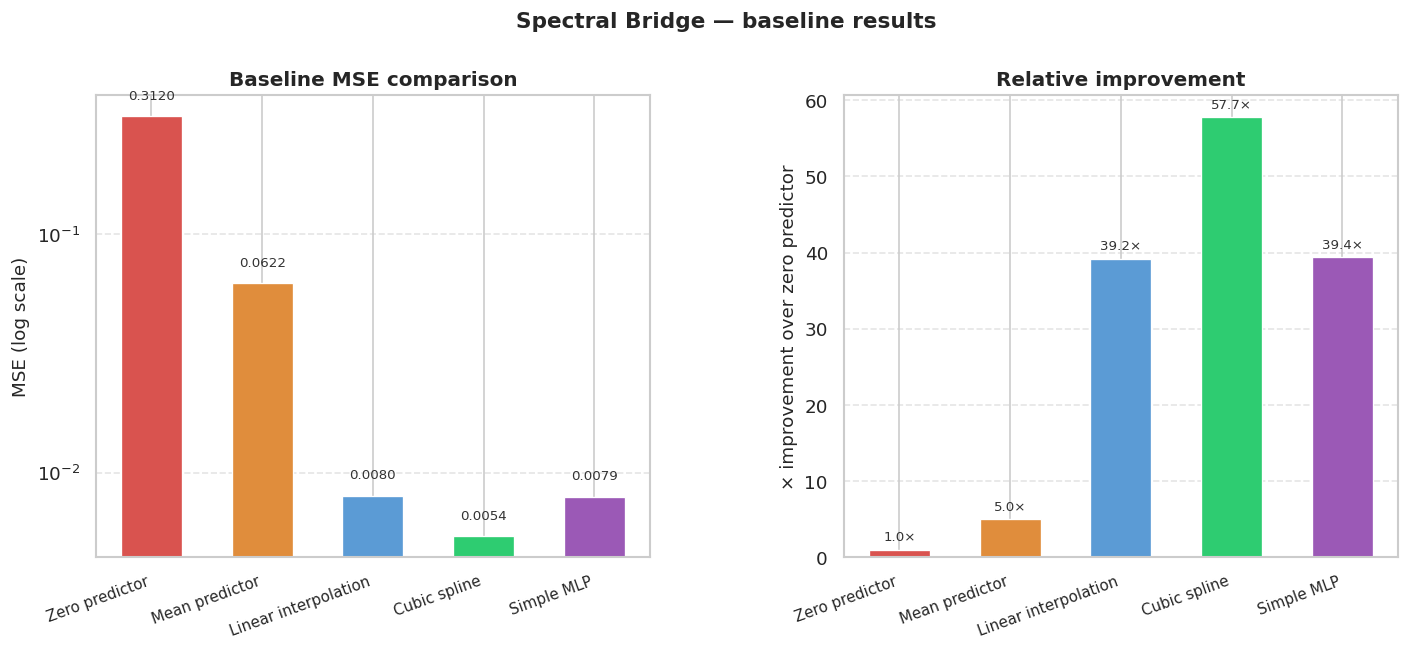

Plot saved to Google Drive.


In [ ]:
# ── Cell 11: Baseline comparison — plots ──────────────────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

results = {
    "Zero predictor":       0.311986,
    "Mean predictor":       0.062171,
    "Linear interpolation": 0.007958,
    "Cubic spline":         0.005403,
    "Simple MLP":           0.007928,
}

names  = list(results.keys())
mses   = list(results.values())
colors = ["#d9534f", "#e08d3c", "#5b9bd5", "#2ecc71", "#9b59b6"]

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ── left: bar chart (log scale) ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
bars = ax1.bar(names, mses, color=colors, width=0.55, edgecolor="white", linewidth=0.8)
ax1.set_yscale("log")
ax1.set_ylabel("MSE (log scale)", fontsize=11)
ax1.set_title("Baseline MSE comparison", fontsize=12, fontweight="bold")
ax1.set_xticks(range(len(names)))
ax1.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
ax1.yaxis.grid(True, linestyle="--", alpha=0.5)
ax1.set_axisbelow(True)

for bar, val in zip(bars, mses):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.15,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=8, color="#333333"
    )

# ── right: improvement over zero predictor ────────────────────────────────
ax2 = fig.add_subplot(gs[1])
zero_mse    = results["Zero predictor"]
improvements = [zero_mse / v for v in mses]

bars2 = ax2.bar(names, improvements, color=colors, width=0.55,
                edgecolor="white", linewidth=0.8)
ax2.set_ylabel("× improvement over zero predictor", fontsize=11)
ax2.set_title("Relative improvement", fontsize=12, fontweight="bold")
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
ax2.yaxis.grid(True, linestyle="--", alpha=0.5)
ax2.set_axisbelow(True)

for bar, val in zip(bars2, improvements):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{val:.1f}×",
        ha="center", va="bottom", fontsize=8, color="#333333"
    )

plt.suptitle("Spectral Bridge — baseline results", fontsize=13, fontweight="bold", y=1.02)
plt.savefig("/content/drive/MyDrive/spectral-bridge/results/plots/baseline_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to Google Drive.")

In [13]:
# ── Cell 12: Notebook summary ─────────────────────────────────────────────

summary = {
    "Zero predictor":       0.311986,
    "Mean predictor":       0.062171,
    "Linear interpolation": 0.007958,
    "Cubic spline":         0.005403,
    "Simple MLP":           0.007928,
}

zero_mse = summary["Zero predictor"]
best_name = min(summary, key=summary.get)
best_mse  = summary[best_name]

print("=" * 58)
print("  SPECTRAL BRIDGE — Baseline Results")
print("=" * 58)
print(f"  {'Method':<25} {'MSE':>10}  {'vs Zero':>10}")
print("-" * 58)
for name, mse in summary.items():
    marker = " ◄" if name == best_name else ""
    print(f"  {name:<25} {mse:>10.6f}  {zero_mse/mse:>9.1f}×{marker}")
print("=" * 58)
print()
print(f"  Best baseline : {best_name}")
print(f"  Best MSE      : {best_mse:.6f}")
print(f"  Transformer target : beat {best_mse:.6f} (notebook 03)")
print()
print("  Key observations:")
print("  • Interpolation methods dominate — signal is smooth")
print("  • MLP (0.007928) < linear interp (0.007958) — marginal")
print("  • Cubic spline sets the bar for notebook 03")
print("  • Transformer should leverage full sequence context")
print("=" * 58)

  SPECTRAL BRIDGE — Baseline Results
  Method                           MSE     vs Zero
----------------------------------------------------------
  Zero predictor              0.311986        1.0×
  Mean predictor              0.062171        5.0×
  Linear interpolation        0.007958       39.2×
  Cubic spline                0.005403       57.7× ◄
  Simple MLP                  0.007928       39.4×

  Best baseline : Cubic spline
  Best MSE      : 0.005403
  Transformer target : beat 0.005403 (notebook 03)

  Key observations:
  • Interpolation methods dominate — signal is smooth
  • MLP (0.007928) < linear interp (0.007958) — marginal
  • Cubic spline sets the bar for notebook 03
  • Transformer should leverage full sequence context
